In [1]:
import boto3
import icechunk
import matplotlib.pyplot as plt
import xarray as xr

from srm import catalog

In [2]:
def open_icechunk(path):
    bucket, prefix = path.replace("s3://", "").split("/", 1)
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")

    ds = xr.open_dataset(session.store, engine="zarr", chunks={})
    return ds

In [3]:
def get_fname(var, scenario, version="test011_add_tasmin", ens="007"):
    fname = (
        "s3://carbonplan-scratch/srm/outputs/qa/"
        + version
        + "/"
        + scenario
        + "/CESM2-WACCM/"
        + var
        + "/"
        + ens
        + "/lat-32.64to-26.58_lon25.05to31.39/*/"
        + scenario
        + ".icechunk/"
    )

    return fname

In [4]:
def resolve_s3_glob(path):
    """Resolve a single * wildcard in an S3 path to a real path."""
    bucket, prefix = path.replace("s3://", "").split("/", 1)

    before, after = prefix.split("*/", 1)

    s3 = boto3.client("s3")
    response = s3.list_objects_v2(Bucket=bucket, Prefix=before, Delimiter="/")

    matches = [f"s3://{bucket}/{cp['Prefix']}{after}" for cp in response.get("CommonPrefixes", [])]

    if not matches:
        raise ValueError(f"No S3 paths matched: {path}")
    if len(matches) > 1:
        raise ValueError(f"Multiple matches: {matches}")

    return matches[0]

In [5]:
hist_ds = (
    catalog.get("pangeo-CESM2-WACCM-historical-icechunk")
    .to_xarray()
    .sel(ensemble_member="r2i1p1f1")
    .sel(lon=slice(25, 32), lat=slice(-33, -25))
).sel(time=slice("1978", "2015"))

hist_ds2 = (
    catalog.get("CESM2-WACCM-historical-icechunk")
    .to_xarray()
    .sel(ensemble_member="001")
    .sel(lon=slice(25, 32), lat=slice(-33, -25))
).sel(time=slice("1978", "2015"))

scenario_ds = (
    catalog.get("CESM2-WACCM-SSP245-icechunk")
    .to_xarray()
    .sel(ensemble_member="007")
    .sel(lon=slice(25, 32), lat=slice(-33, -25))
).sel(time=slice("2015", "2070"))

### tas

In [7]:
var = "tas"

fname = get_fname(var=var, scenario="historical", ens="r2i1p1f1")
fname = resolve_s3_glob(fname)
historical_downscaled_var = open_icechunk(path=fname)[var]

fname = get_fname(var=var, scenario="ssp245", ens="007")
fname = resolve_s3_glob(fname)
scenario_downscaled_var = open_icechunk(path=fname)[var]

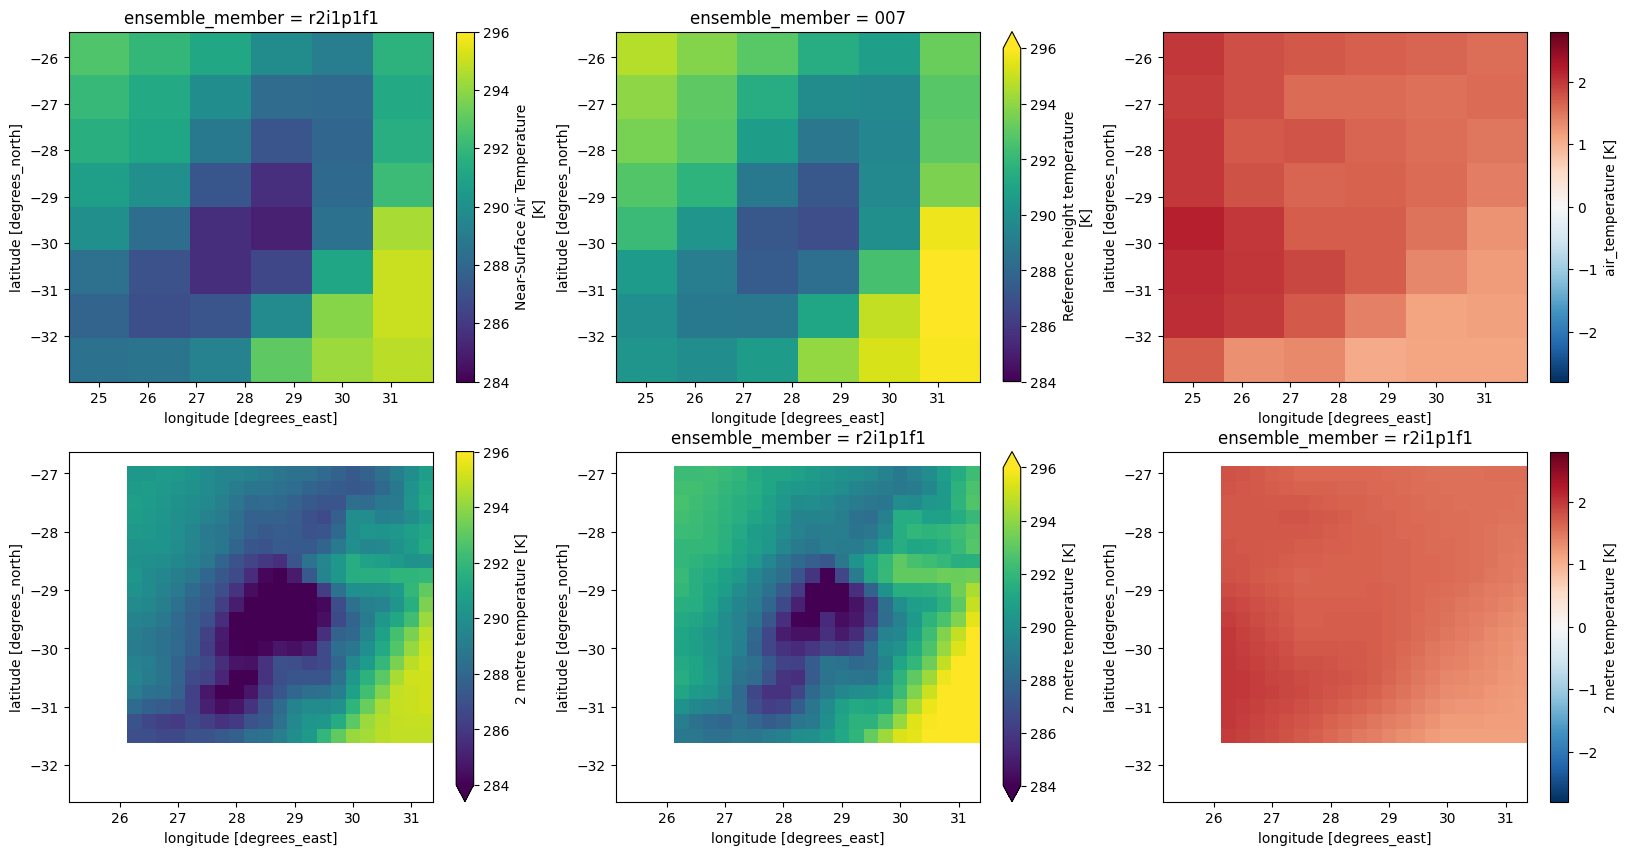

In [8]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

vmax = 296
vmin = 284
vmax_delta = 2.8
vmin_delta = -2.8

ax = axs[0, 0]
hist_coarse = hist_ds[var].mean(dim="time").load()
hist_coarse.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[0, 1]
scenario_coarse = scenario_ds[var].mean(dim="time").load()
scenario_coarse.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[0, 2]
delta_coarse = scenario_coarse - hist_coarse
delta_coarse.plot(ax=ax, vmax=vmax_delta, vmin=vmin_delta, cmap=plt.cm.RdBu_r)

ax = axs[1, 0]
historical_downscaled = historical_downscaled_var.mean(dim="time").load()
historical_downscaled.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[1, 1]
scenario_downscaled = scenario_downscaled_var.mean(dim="time").load()
scenario_downscaled.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[1, 2]
delta_downscaled = scenario_downscaled - historical_downscaled
delta_downscaled.plot(ax=ax, vmax=vmax_delta, vmin=vmin_delta, cmap=plt.cm.RdBu_r)

### tasmax

In [9]:
var = "tasmax"

fname = get_fname(var=var, scenario="historical", ens="001")
fname = resolve_s3_glob(fname)
historical_downscaled_var = open_icechunk(path=fname)[var]

fname = get_fname(var=var, scenario="ssp245", ens="007")
fname = resolve_s3_glob(fname)
scenario_downscaled_var = open_icechunk(path=fname)[var]

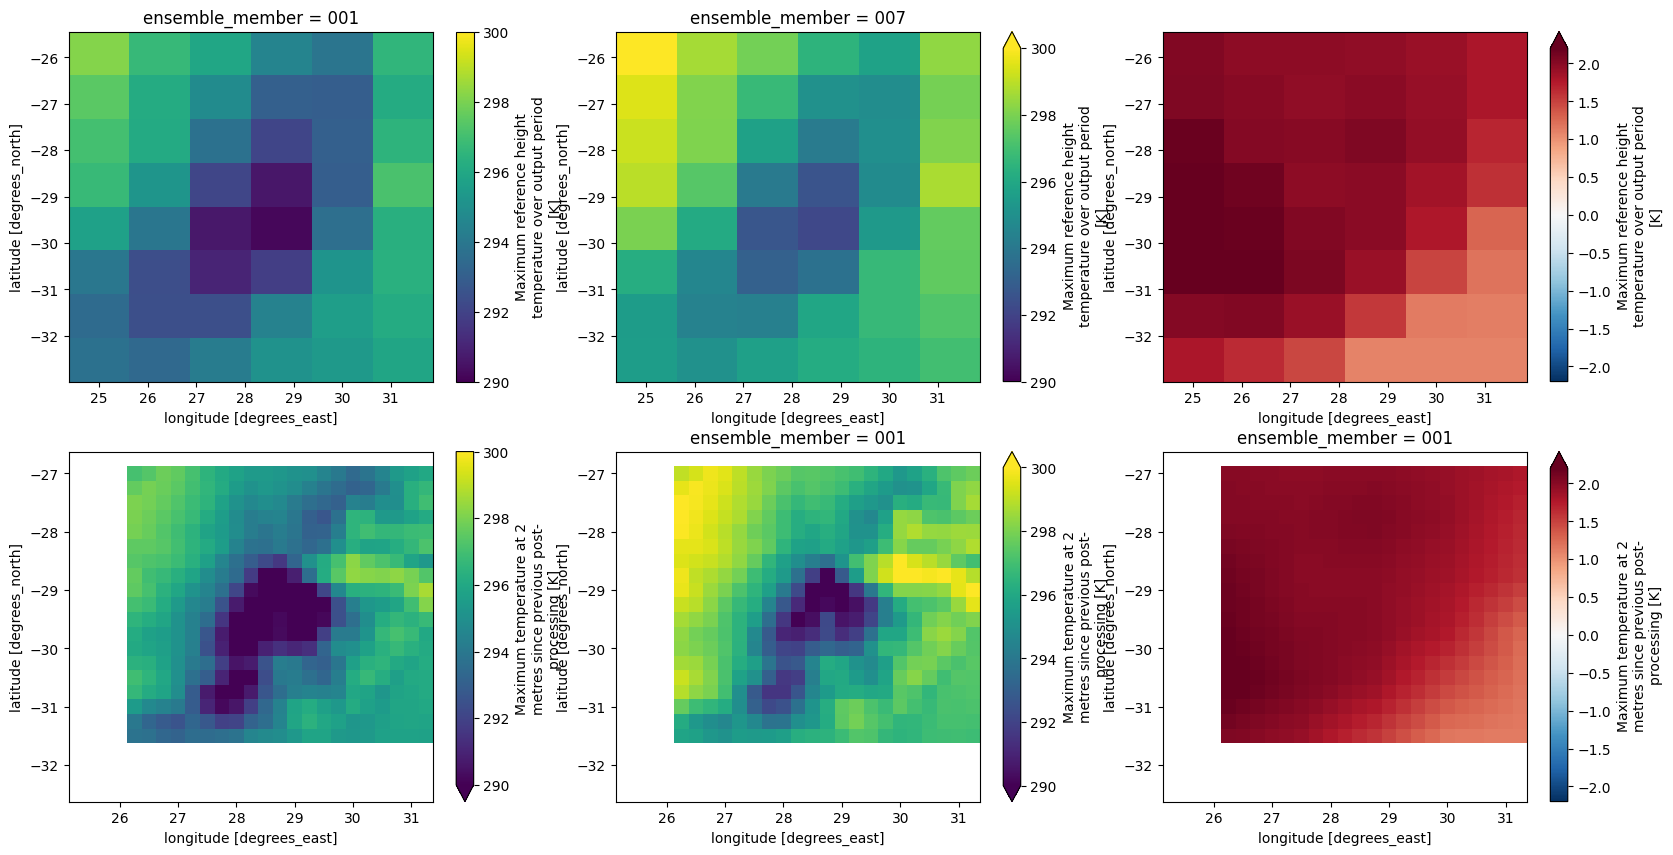

In [10]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

vmax = 300
vmin = 290
vmax_delta = 2.2
vmin_delta = -2.2

ax = axs[0, 0]
hist_coarse = hist_ds2[var].mean(dim="time").load()
hist_coarse.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[0, 1]
scenario_coarse = scenario_ds[var].mean(dim="time").load()
scenario_coarse.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[0, 2]
delta_coarse = scenario_coarse - hist_coarse
delta_coarse.plot(ax=ax, vmax=vmax_delta, vmin=vmin_delta, cmap=plt.cm.RdBu_r)

ax = axs[1, 0]
historical_downscaled = historical_downscaled_var.mean(dim="time").load()
historical_downscaled.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[1, 1]
scenario_downscaled = scenario_downscaled_var.mean(dim="time").load()
scenario_downscaled.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[1, 2]
delta_downscaled = scenario_downscaled - historical_downscaled
delta_downscaled.plot(ax=ax, vmax=vmax_delta, vmin=vmin_delta, cmap=plt.cm.RdBu_r)

### tasmin

In [19]:
var = "tasmin"

fname = get_fname(var=var, scenario="historical", ens="001")
fname = resolve_s3_glob(fname)
historical_downscaled_var = open_icechunk(path=fname)[var]

fname = get_fname(var=var, scenario="ssp245", ens="007")
fname = resolve_s3_glob(fname)
scenario_downscaled_var = open_icechunk(path=fname)[var]

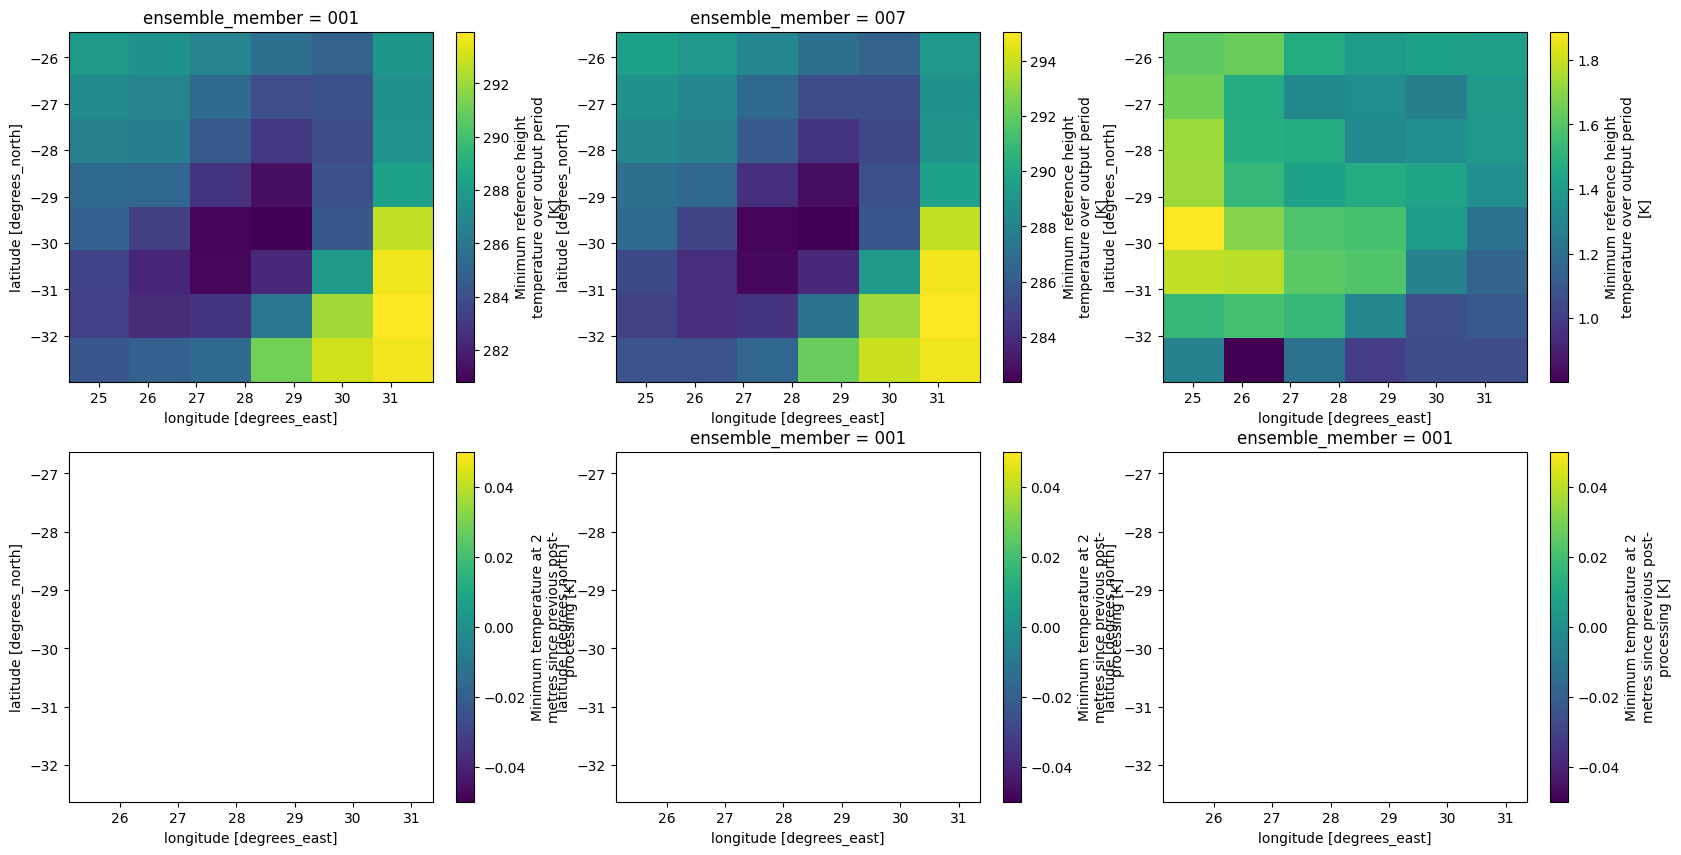

In [18]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

vmax = 300
vmin = 290
vmax_delta = 2.2
vmin_delta = -2.2

ax = axs[0, 0]
hist_coarse = hist_ds2[var].mean(dim="time").load()
hist_coarse.plot(ax=ax)  # , vmax=vmax, vmin=vmin)

ax = axs[0, 1]
scenario_coarse = scenario_ds[var].mean(dim="time").load()
scenario_coarse.plot(ax=ax)  # , vmax=vmax, vmin=vmin)

ax = axs[0, 2]
delta_coarse = scenario_coarse - hist_coarse
delta_coarse.plot(ax=ax)  # , vmax=vmax_delta, vmin=vmin_delta, cmap=plt.cm.RdBu_r)

ax = axs[1, 0]
historical_downscaled = historical_downscaled_var.mean(dim="time").load()
historical_downscaled.plot(ax=ax)  # , vmax=vmax, vmin=vmin)

ax = axs[1, 1]
scenario_downscaled = scenario_downscaled_var.mean(dim="time").load()
scenario_downscaled.plot(ax=ax)  # , vmax=vmax, vmin=vmin)

ax = axs[1, 2]
delta_downscaled = scenario_downscaled - historical_downscaled
delta_downscaled.plot(ax=ax)  # , vmax=vmax_delta, vmin=vmin_delta, cmap=plt.cm.RdBu_r)

### pr

In [11]:
var = "pr"

fname = get_fname(var=var, scenario="historical", ens="r2i1p1f1")
fname = resolve_s3_glob(fname)
historical_downscaled_var = open_icechunk(path=fname)[var]

fname = get_fname(var=var, scenario="ssp245", ens="007")
fname = resolve_s3_glob(fname)
scenario_downscaled_var = open_icechunk(path=fname)[var]

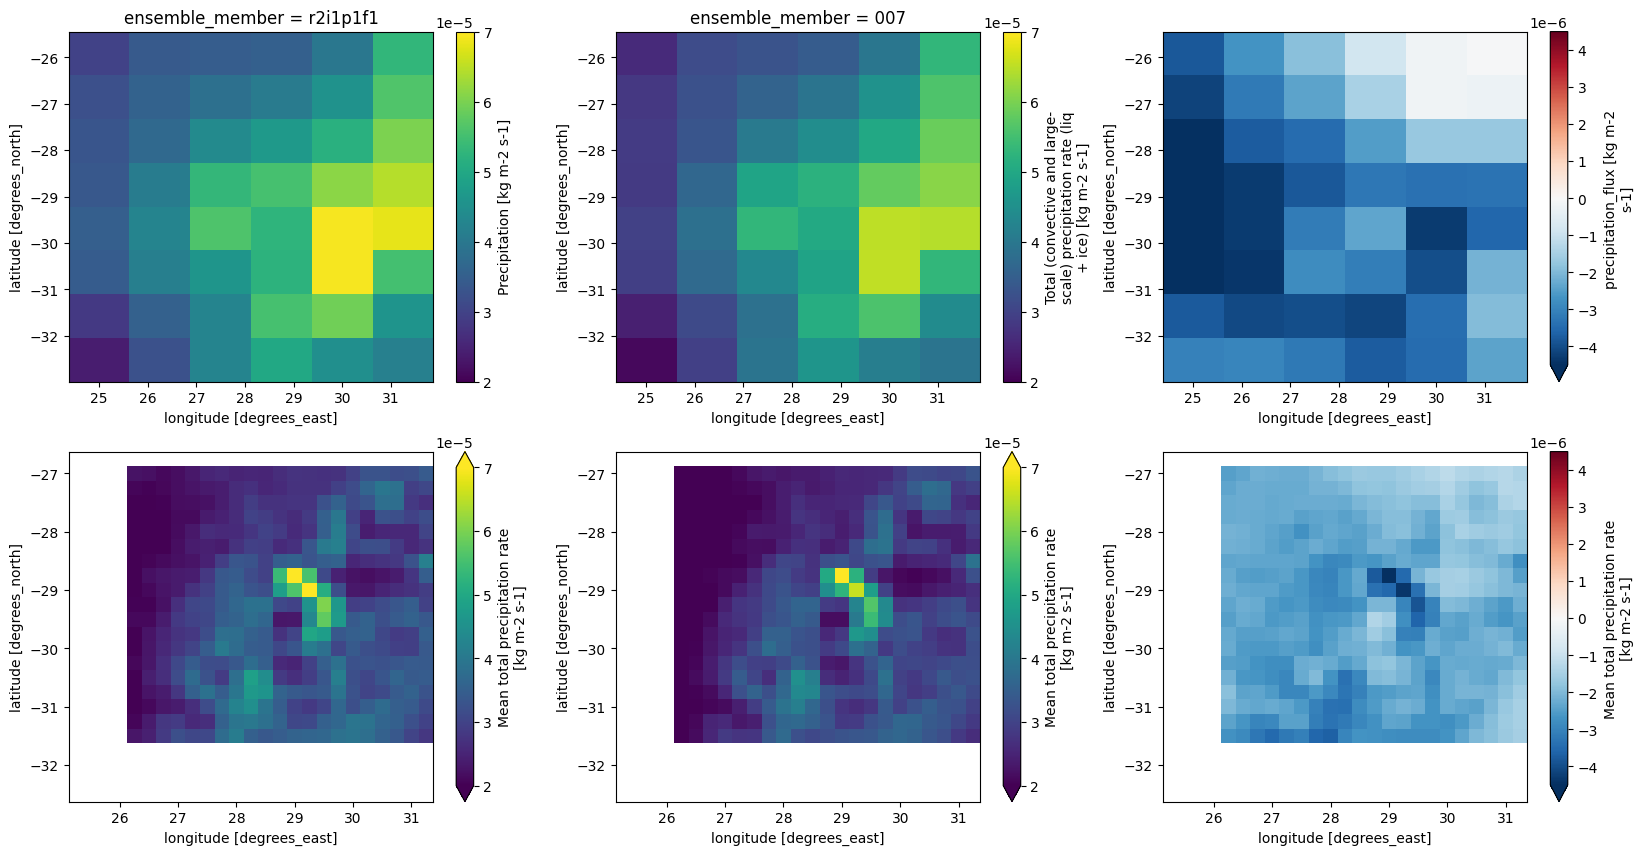

In [12]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

vmax = 7e-5
vmin = 2e-5
vmax_delta = 4.5e-6
vmin_delta = -4.5e-6

ax = axs[0, 0]
hist_coarse = hist_ds[var].mean(dim="time").load()
hist_coarse.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[0, 1]
scenario_coarse = scenario_ds[var].mean(dim="time").load()
scenario_coarse.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[0, 2]
delta_coarse = scenario_coarse - hist_coarse
delta_coarse.plot(ax=ax, vmax=vmax_delta, vmin=vmin_delta, cmap=plt.cm.RdBu_r)

ax = axs[1, 0]
historical_downscaled = historical_downscaled_var.mean(dim="time").load()
historical_downscaled.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[1, 1]
scenario_downscaled = scenario_downscaled_var.mean(dim="time").load()
scenario_downscaled.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[1, 2]
delta_downscaled = scenario_downscaled - historical_downscaled
delta_downscaled.plot(ax=ax, vmax=vmax_delta, vmin=vmin_delta, cmap=plt.cm.RdBu_r)

### rsds

In [13]:
var = "rsds"

fname = get_fname(var=var, scenario="historical", ens="r2i1p1f1")
fname = resolve_s3_glob(fname)
historical_downscaled_var = open_icechunk(path=fname)[var]

fname = get_fname(var=var, scenario="ssp245", ens="007")
fname = resolve_s3_glob(fname)
scenario_downscaled_var = open_icechunk(path=fname)[var]

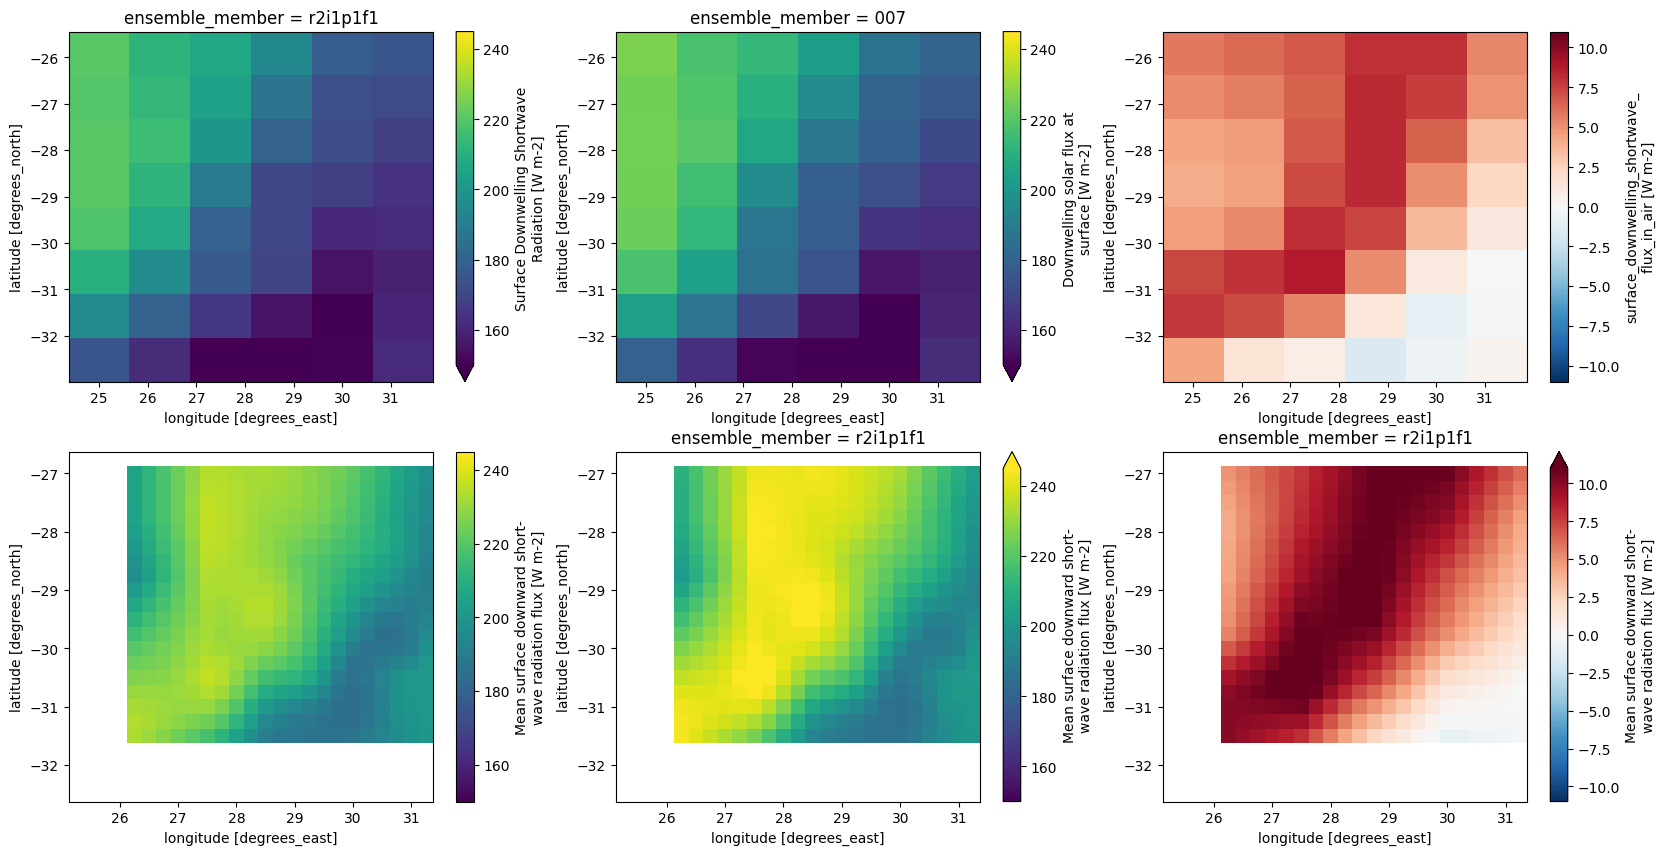

In [14]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

vmax = 245
vmin = 150
vmax_delta = 11
vmin_delta = -11

ax = axs[0, 0]
hist_coarse = hist_ds[var].mean(dim="time").load()
hist_coarse.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[0, 1]
scenario_coarse = scenario_ds[var].mean(dim="time").load()
scenario_coarse.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[0, 2]
delta_coarse = scenario_coarse - hist_coarse
delta_coarse.plot(ax=ax, vmax=vmax_delta, vmin=vmin_delta, cmap=plt.cm.RdBu_r)

ax = axs[1, 0]
historical_downscaled = historical_downscaled_var.mean(dim="time").load()
historical_downscaled.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[1, 1]
scenario_downscaled = scenario_downscaled_var.mean(dim="time").load()
scenario_downscaled.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[1, 2]
delta_downscaled = scenario_downscaled - historical_downscaled
delta_downscaled.plot(ax=ax, vmax=vmax_delta, vmin=vmin_delta, cmap=plt.cm.RdBu_r)

### hurs

In [15]:
var = "hurs"

fname = get_fname(var=var, scenario="historical", ens="r2i1p1f1")
fname = resolve_s3_glob(fname)
historical_downscaled_var = open_icechunk(path=fname)[var]

fname = get_fname(var=var, scenario="ssp245", ens="007")
fname = resolve_s3_glob(fname)
scenario_downscaled_var = open_icechunk(path=fname)[var]

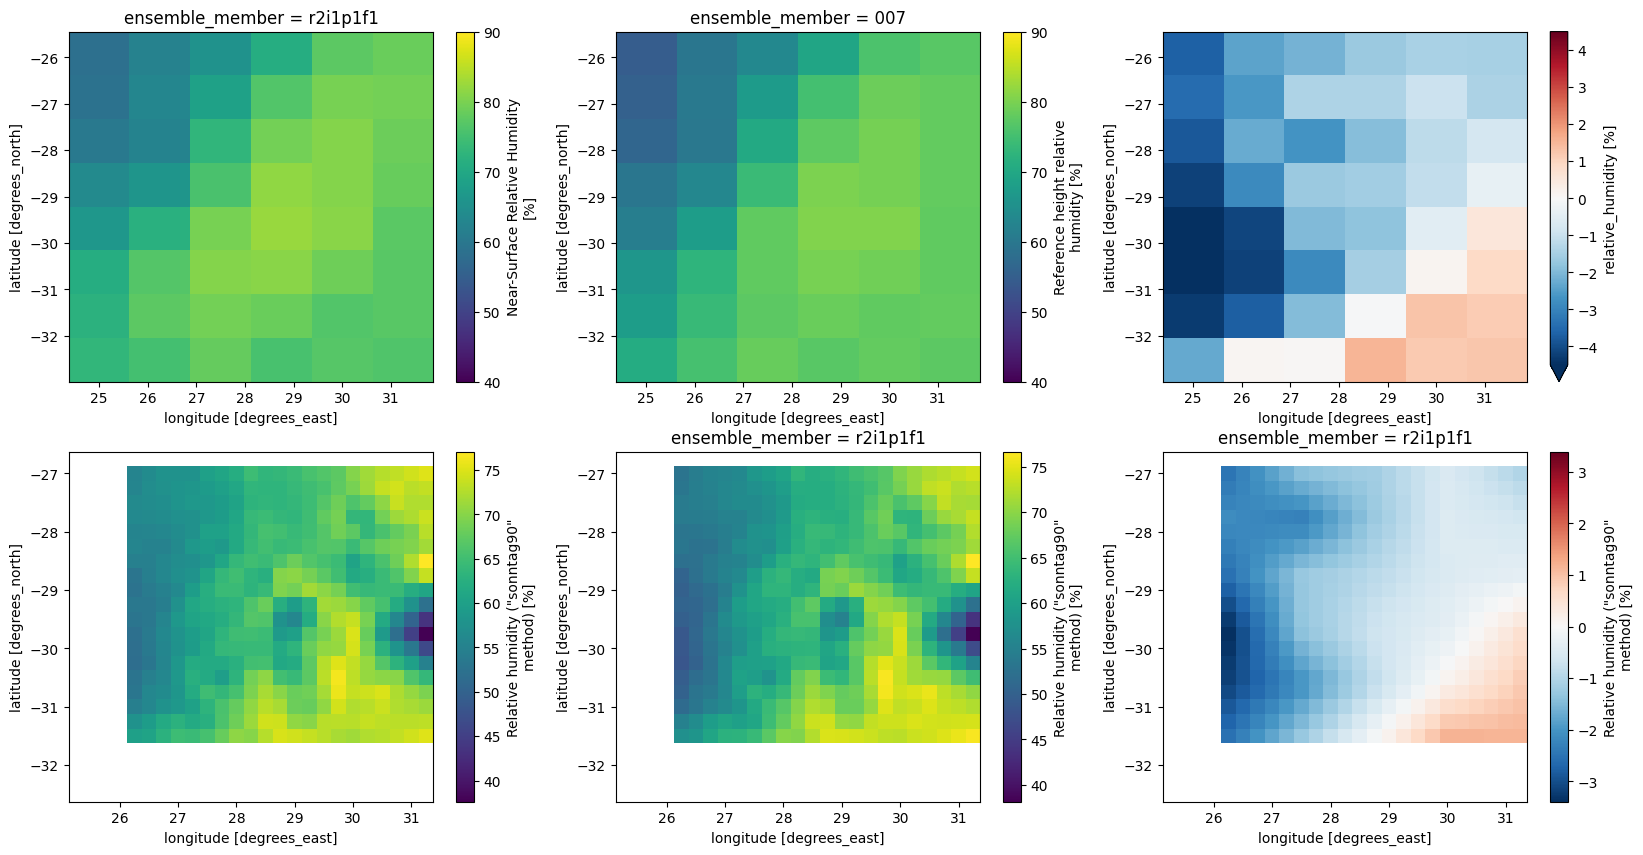

In [16]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

vmax = 90
vmin = 40
vmax_delta = 4.5
vmin_delta = -4.5

ax = axs[0, 0]
hist_coarse = hist_ds[var].mean(dim="time").load()
hist_coarse.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[0, 1]
scenario_coarse = scenario_ds[var].mean(dim="time").load()
scenario_coarse.plot(ax=ax, vmax=vmax, vmin=vmin)

ax = axs[0, 2]
delta_coarse = scenario_coarse - hist_coarse
delta_coarse.plot(ax=ax, vmax=vmax_delta, vmin=vmin_delta, cmap=plt.cm.RdBu_r)

ax = axs[1, 0]
historical_downscaled = historical_downscaled_var.mean(dim="time").load()
historical_downscaled.plot(ax=ax)  # , vmax=vmax, vmin=vmin)

ax = axs[1, 1]
scenario_downscaled = scenario_downscaled_var.mean(dim="time").load()
scenario_downscaled.plot(ax=ax)  # , vmax=vmax, vmin=vmin)

ax = axs[1, 2]
delta_downscaled = scenario_downscaled - historical_downscaled
delta_downscaled.plot(ax=ax)  # , vmax=vmax_delta, vmin=vmin_delta, cmap=plt.cm.RdBu_r)